In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Change le répertoire de travail vers ton dossier
%cd "/content/drive/MyDrive/Projet Big Data"

/content/drive/MyDrive/Projet Big Data


In [5]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [6]:
from utils_AS import *

In [ ]:
Churn_Modelling=pd.read_csv('./data/Churn_Modelling.csv')

In [ ]:
Churn_Modelling

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
print("--- Informations Générales ---")
print(Churn_Modelling.info())


--- Informations Générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [ ]:
# Suppression des colonnes d'identification pour l'analyse
# On crée une copie pour ne pas perdre les ID originaux
df_analysis = Churn_Modelling.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [ ]:
import seaborn as sns

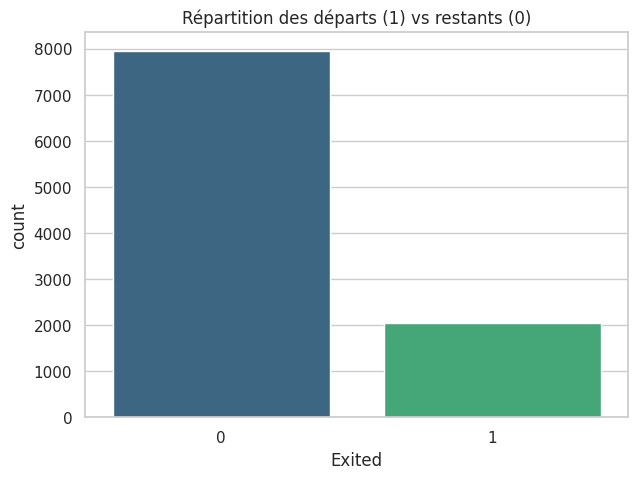

In [ ]:

# 3. Visualisations
sns.set(style="whitegrid")

# A. Répartition du Churn
plt.figure(figsize=(7, 5))
sns.countplot(x='Exited', data=Churn_Modelling, palette='viridis')
plt.title('Répartition des départs (1) vs restants (0)')
plt.show()


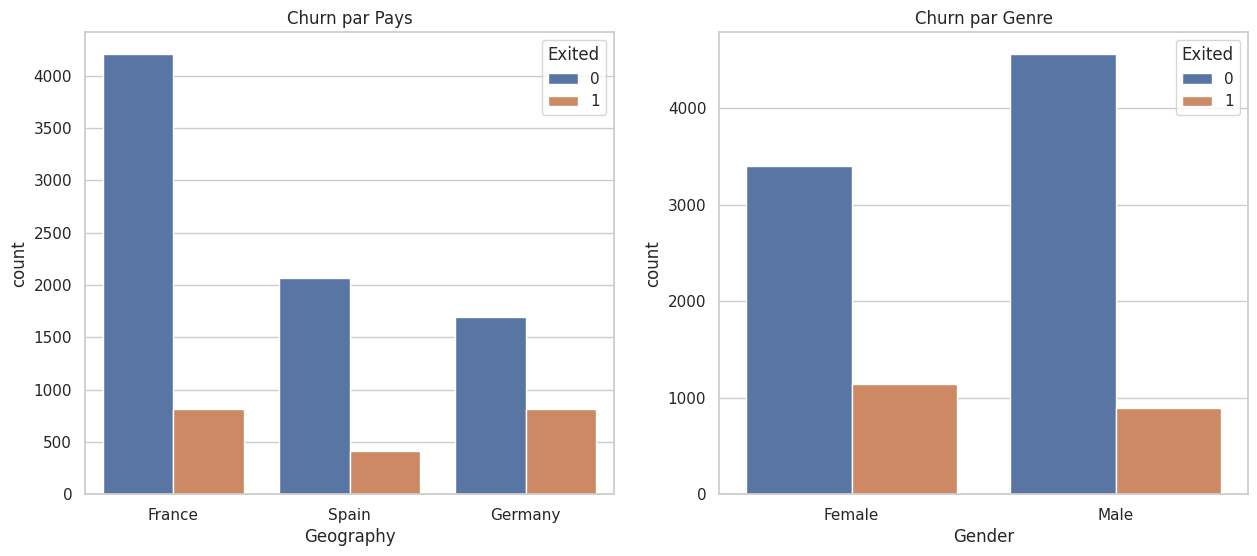

In [ ]:

# B. Analyse Géographique et Genre
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='Geography', hue='Exited', data=Churn_Modelling, ax=axes[0])
axes[0].set_title('Churn par Pays')

sns.countplot(x='Gender', hue='Exited', data=Churn_Modelling, ax=axes[1])
axes[1].set_title('Churn par Genre')
plt.show()


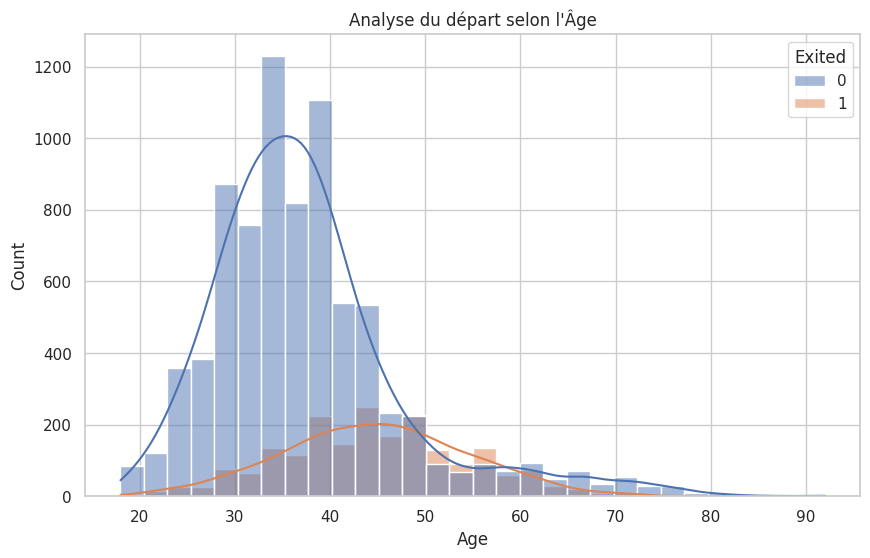

In [ ]:

# C. Impact de l'Âge
plt.figure(figsize=(10, 6))
sns.histplot(data=Churn_Modelling, x='Age', hue='Exited', kde=True, bins=30)
plt.title('Analyse du départ selon l\'Âge')
plt.show()


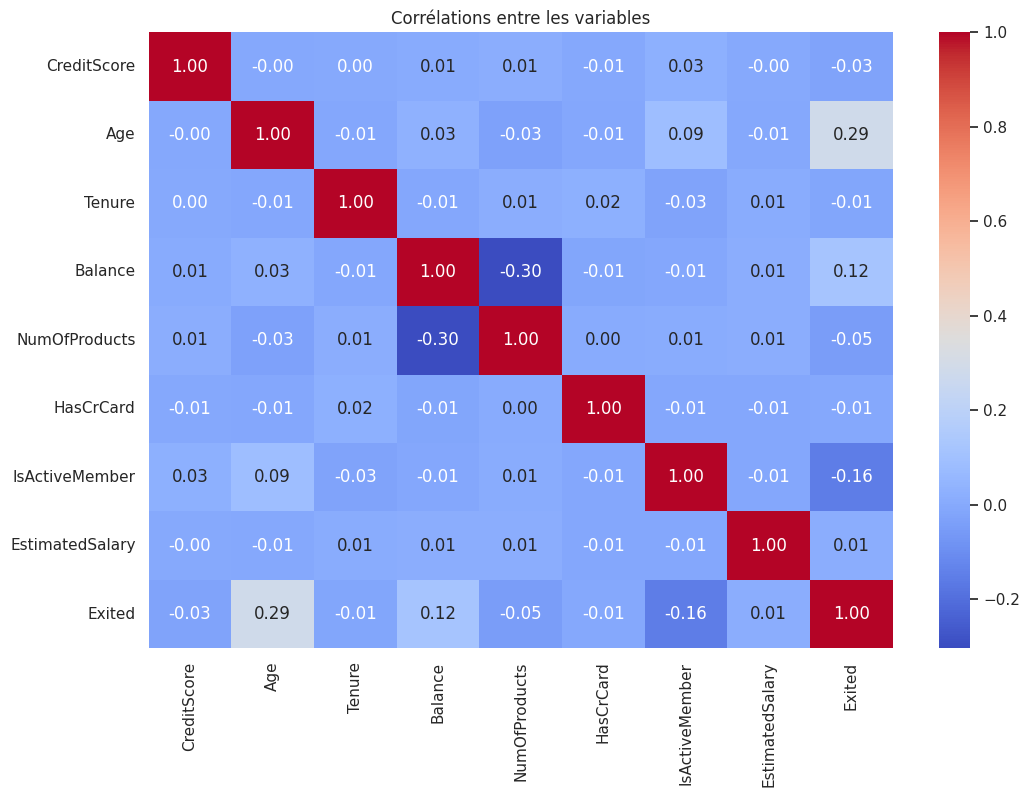

In [ ]:

# D. Matrice de Corrélation (Variables numériques uniquement)
plt.figure(figsize=(12, 8))
numeric_cols = df_analysis.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélations entre les variables')
plt.show()


In [7]:
import pandas as pd
import numpy as np
import time
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, accuracy_score, precision_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configuration de base
SEED = 42
Churn_Modelling = pd.read_csv('./data/Churn_Modelling.csv')

# 1. Séparation X et Y
X_raw = Churn_Modelling.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
Y = Churn_Modelling['Exited']

# 2. Pipeline de transformation (Indispensable pour MLP, KNN, etc.)
categorical_features = ['Geography', 'Gender']
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# X prêt pour la Cross-Validation
X_transformed = preprocessor.fit_transform(X_raw)

# Récupération des noms des variables pour la suite
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features_names = np.concatenate([numeric_features, cat_names])

In [8]:

from sklearn.metrics import fbeta_score, make_scorer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# Fonction de score personnalisée (F2-Score)
def custom_metric(y_true, y_pred):
    # beta=2 permet de favoriser le rappel (détection des départs)
    return fbeta_score(y_true, y_pred, beta=2, zero_division=0)

custom_scorer = make_scorer(custom_metric)



clfs = {
    'LogisticReg': LogisticRegression(max_iter=1000, random_state=SEED),
    'CART': DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(50, 25), random_state=SEED, max_iter=400),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Bagging': BaggingClassifier(n_estimators=200, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=SEED),
    'RF': RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced'),
    'GradBoost': GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED)
}

In [9]:
def run_classifiers_cv(X, Y, classifiers):
    kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
    results = []

    print(f"{'Algorithm':<15} | {'Accuracy':<10} | {'AUC':<10} | {'MyScore':<10} | {'Time':<7}")
    print("-" * 65)

    for name, model in classifiers.items():
        start_time = time.time()

        # Calcul des métriques par CV
        cv_acc = cross_val_score(model, X, Y, cv=kf, scoring='accuracy')
        cv_auc = cross_val_score(model, X, Y, cv=kf, scoring='roc_auc')
        cv_custom = cross_val_score(model, X, Y, cv=kf, scoring=custom_scorer)

        exec_time = time.time() - start_time

        print(f"{name:<15} | {np.mean(cv_acc):.3f}      | {np.mean(cv_auc):.3f}   | {np.mean(cv_custom):.3f}   | {exec_time:.2f}s")



In [10]:
# Lancement de l'analyse
run_classifiers_cv(X_transformed, Y, clfs)

Algorithm       | Accuracy   | AUC        | MyScore    | Time   
-----------------------------------------------------------------
LogisticReg     | 0.811      | 0.766   | 0.245   | 0.38s
CART            | 0.855      | 0.835   | 0.470   | 0.84s
MLP             | 0.840      | 0.826   | 0.525   | 406.12s
KNN             | 0.839      | 0.801   | 0.426   | 2.91s
Bagging         | 0.857      | 0.847   | 0.523   | 264.76s
AdaBoost        | 0.855      | 0.846   | 0.494   | 48.43s
RF              | 0.861      | 0.852   | 0.491   | 83.23s
GradBoost       | 0.863      | 0.865   | 0.522   | 99.45s
SVM             | 0.856      | 0.823   | 0.429   | 289.16s


In [10]:
def importances_variables(Xtrain, Ytrain, features):
    # On utilise un Random Forest robuste pour calculer l'importance
    RF = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)
    RF.fit(Xtrain, Ytrain)

    importances = RF.feature_importances_
    # Calcul de l'écart-type pour les barres d'erreur
    std = np.std([tree.feature_importances_ for tree in RF.estimators_], axis=0)
    # Tri des variables
    sorted_idx = np.argsort(importances)[::-1]

    # Affichage graphique
    padding = np.arange(len(features)) + 0.5
    plt.figure(figsize=(10, 8))
    plt.barh(padding, importances[sorted_idx], xerr=std[sorted_idx], align='center')
    plt.yticks(padding, features[sorted_idx])
    plt.xlabel("Importance Relative")
    plt.title("Importance des Variables (Random Forest)")
    plt.gca().invert_yaxis()
    plt.show()

    return RF, sorted_idx


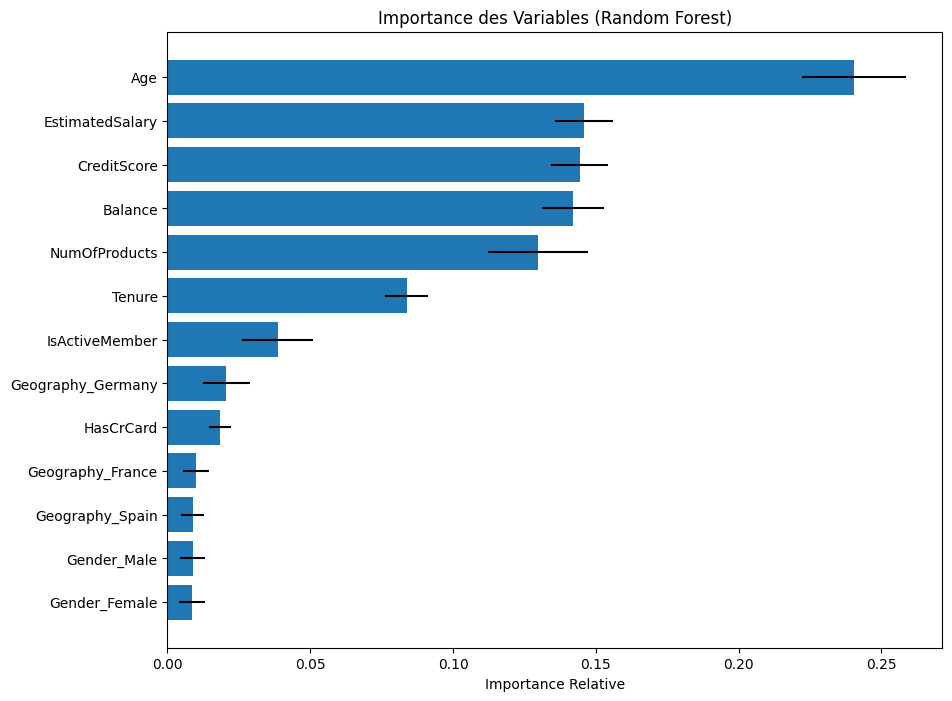

In [11]:

# Calcul de l'importance sur les données transformées
RF_model, ordre_features = importances_variables(X_transformed, Y, all_features_names)

In [12]:
def evolution_features(X, Y, clf, sorted_idx, score_func):
    # On split pour avoir un jeu de test fixe pour la courbe d'évolution
    X1, X2, Y1, Y2 = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=SEED)

    scores = np.zeros(X.shape[1])

    print("Calcul de l'évolution du score...")
    for f in np.arange(0, X.shape[1]):
        # Sélection progressive des variables selon l'ordre d'importance
        X1_f = X1[:, sorted_idx[:f+1]]
        X2_f = X2[:, sorted_idx[:f+1]]

        clf.fit(X1_f, Y1)
        Ypred = clf.predict(X2_f)
        # On utilise votre score personnalisé (Acc + Prec) / 2
        scores[f] = np.round(score_func(Y2, Ypred), 3)

    # Affichage de la courbe
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(1, len(scores) + 1), scores, marker='o')
    plt.xlabel("Nombre de Variables")
    plt.ylabel("Score (Accuracy + Precision) / 2")
    plt.title("Evolution du score en fonction du nombre de variables")
    plt.grid(True)
    plt.show()

    # Sélection des meilleurs indices
    best_nb = np.argmax(scores) + 1
    selected_features = sorted_idx[:best_nb]

    print(f"Meilleur score de {np.max(scores)} atteint avec {best_nb} variables.")
    return scores, selected_features

# Utilisation du MLP pour l'évolution (comme dans votre TP)
from sklearn.neural_network import MLPClassifier
clf_mlp = MLPClassifier(hidden_layer_sizes=(20, 10), random_state=SEED, max_iter=500)


Calcul de l'évolution du score...


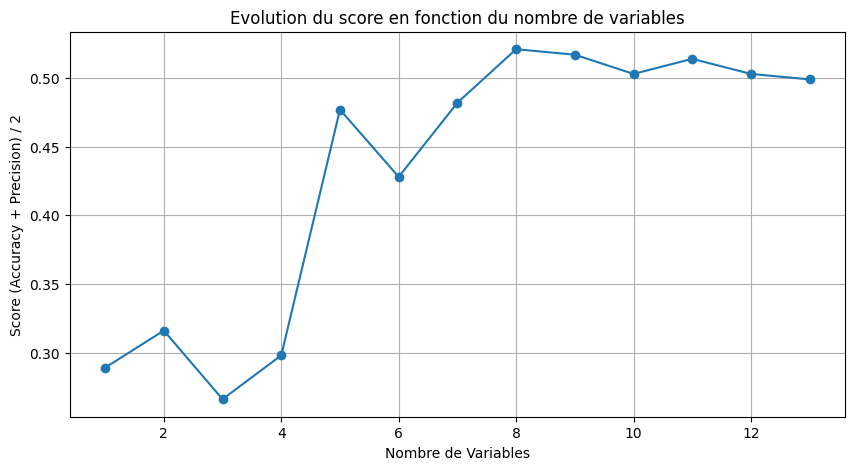

Meilleur score de 0.521 atteint avec 8 variables.


In [13]:

scores, selected_features = evolution_features(X_transformed, Y, clf_mlp, ordre_features, custom_metric)

In [15]:
from sklearn.model_selection import GridSearchCV

def recherche_parametres(clf, params, X, Y, scorer):
    print(f"Optimisation du modèle...")
    grid = GridSearchCV(clf, params, cv=5, scoring=scorer, n_jobs=-1)
    grid.fit(X, Y)

    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(f"Meilleur score : {grid.best_score_:.3f}")

    return grid.best_estimator_

# Exemple pour Gradient Boosting
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5]
}


In [16]:

# On utilise uniquement les variables sélectionnées précédemment
best_gb = recherche_parametres(clfs['GradBoost'], param_gb, X_transformed[:, selected_features], Y, custom_scorer)

Optimisation du modèle...
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Meilleur score : 0.528


In [17]:
def recherche_meilleur_seuil(model, X_test, Y_test):
    from sklearn.metrics import fbeta_score

    # Récupérer les probabilités de la classe 1 (départ)
    probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_threshold = 0.5
    best_score = 0

    for t in thresholds:
        preds = (probs >= t).astype(int)
        score = fbeta_score(Y_test, preds, beta=2)
        if score > best_score:
            best_score = score
            best_threshold = t

    print(f"Seuil optimal pour favoriser le rappel : {best_threshold:.2f}")
    return best_threshold

# Utilisation
X_train, X_test, Y_train, Y_test = train_test_split(X_transformed[:, selected_features], Y, test_size=0.2, random_state=SEED)
best_gb.fit(X_train, Y_train)
seuil_final = recherche_meilleur_seuil(best_gb, X_test, Y_test)

Seuil optimal pour favoriser le rappel : 0.17


In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import fbeta_score, classification_report

# 1. Définition des fonctions de recherche
def recherche_parametres(clf, params, X, Y, scorer):
    print(f"\n--- Optimisation du modèle : {type(clf).__name__} ---")
    grid = GridSearchCV(clf, params, cv=5, scoring=scorer, n_jobs=-1)
    grid.fit(X, Y)
    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(f"Meilleur score (CV) : {grid.best_score_:.3f}")
    return grid.best_estimator_

def recherche_meilleur_seuil(model, X_test, Y_test):
    # Récupérer les probabilités de la classe 1
    probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.05, 0.9, 100)
    best_threshold = 0.5
    best_score = 0

    for t in thresholds:
        preds = (probs >= t).astype(int)
        # On utilise beta=2 pour privilégier le Rappel (Recall) comme demandé
        score = fbeta_score(Y_test, preds, beta=2)
        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score



In [ ]:
# 2. Préparation des données (Assurez-vous que X_transformed et Y sont prêts)
X_final = X_transformed[:, selected_features]
X_train, X_test, Y_train, Y_test = train_test_split(X_final, Y, test_size=0.2, random_state=SEED)

# 3. Définition des grilles de paramètres pour les 3 meilleurs modèles
configs = [
    {
        'name': 'GradBoost',
        'model': clfs['GradBoost'],
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 4, 5]
        }
    },
    {
        'name': 'RandomForest',
        'model': clfs['RF'],
        'params': {
            'n_estimators': [100, 200, 500],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    {
        'name': 'MLP',
        'model': clfs['MLP'],
        'params': {
            'hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'alpha': [0.0001, 0.001],
            'learning_rate_init': [0.001, 0.01]
        }
    }
]

# 4. Exécution et Comparaison
resultats_finaux = []

for config in configs:
    # Optimisation des paramètres
    best_model = recherche_parametres(config['model'], config['params'], X_train, Y_train, custom_scorer)

    # Entraînement final
    best_model.fit(X_train, Y_train)

    # Recherche du seuil optimal sur le set de test
    seuil, score_f2 = recherche_meilleur_seuil(best_model, X_test, Y_test)

    resultats_finaux.append({
        'Algorithme': config['name'],
        'Modèle': best_model,
        'Seuil Optimal': seuil,
        'F2-Score': score_f2
    })

# 5. Affichage du résumé pour faire votre choix
print("\n" + "="*50)
print("COMPARAISON FINALE (Triée par F2-Score)")
print("="*50)
df_comparaison = pd.DataFrame(resultats_finaux).sort_values(by='F2-Score', ascending=False)
print(df_comparaison[['Algorithme', 'Seuil Optimal', 'F2-Score']])

# Pour choisir le meilleur modèle automatiquement :
choix_final = resultats_finaux[0] # Ou celui que vous préférez après lecture


--- Optimisation du modèle : GradientBoostingClassifier ---


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import fbeta_score

# ==========================================================
# 1. PRÉPARATION DES DONNÉES FILTRÉES
# ==========================================================
# On utilise uniquement les variables sélectionnées par l'étape précédente
X_final = X_transformed[:, selected_features]

# Split Train/Test (indispensable pour la recherche du seuil sur données non vues)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_final, Y, test_size=0.2, stratify=Y, random_state=SEED
)


In [15]:

# ==========================================================
# 2. DÉFINITION DES FONCTIONS
# ==========================================================
def recherche_parametres(clf, params, X, Y, scorer):
    print(f"\n--- Optimisation du modèle : {type(clf).__name__} ---")
    # n_jobs=-1 utilise tous les processeurs pour accélérer MLP et RF
    grid = GridSearchCV(clf, params, cv=5, scoring=scorer, n_jobs=-1)
    grid.fit(X, Y)
    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(f"Meilleur score (CV) : {grid.best_score_:.3f}")
    return grid.best_estimator_

def recherche_meilleur_seuil(model, X_test, Y_test):
    """Calcule le seuil de probabilité qui maximise le F2-Score"""
    probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.05, 0.9, 100)
    best_threshold = 0.5
    best_score = 0

    for t in thresholds:
        preds = (probs >= t).astype(int)
        # Beta=2 pour donner la priorité au Rappel (Recall)
        score = fbeta_score(Y_test, preds, beta=2, zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score

In [16]:


# ==========================================================
# 3. CONFIGURATION DES TOP 3 MODÈLES
# ==========================================================
# Basé sur vos résultats : GradBoost, RF, MLP
configs = [
    {
        'name': 'Gradient Boosting',
        'model': clfs['GradBoost'],
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 4, 5]
        }
    },
    {
        'name': 'Random Forest',
        'model': clfs['RF'],
        'params': {
            'n_estimators': [200, 500],
            'max_depth': [10, 20, None],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    {
        'name': 'Multi-Layer Perceptron',
        'model': clfs['MLP'],
        'params': {
            'hidden_layer_sizes': [(50, 25), (100,), (50, 50)],
            'alpha': [0.0001, 0.001],
            'activation': ['relu', 'tanh']
        }
    }
]

In [17]:


# ==========================================================
# 4. EXÉCUTION DE L'OPTIMISATION ET DU SEUILLAGE
# ==========================================================
resultats_finaux = []

for config in configs:
    # A. Recherche des hyperparamètres sur le train set
    best_model = recherche_parametres(config['model'], config['params'], X_train, Y_train, custom_scorer)

    # B. Recherche du seuil optimal sur le test set
    seuil, score_f2 = recherche_meilleur_seuil(best_model, X_test, Y_test)

    resultats_finaux.append({
        'Algorithme': config['name'],
        'Modèle_Objet': best_model,
        'Seuil Optimal': seuil,
        'F2-Score (Test)': round(score_f2, 4)
    })




--- Optimisation du modèle : GradientBoostingClassifier ---
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Meilleur score (CV) : 0.520

--- Optimisation du modèle : RandomForestClassifier ---
Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 500}
Meilleur score (CV) : 0.651

--- Optimisation du modèle : MLPClassifier ---
Meilleurs paramètres : {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50)}
Meilleur score (CV) : 0.519


In [18]:
# ==========================================================
# 5. BILAN ET SÉLECTION FINALE
# ==========================================================
print("\n" + "="*60)
print("COMPARAISON DES TOP 3 APRÈS OPTIMISATION DU SEUIL")
print("="*60)
df_bilan = pd.DataFrame(resultats_finaux).sort_values(by='F2-Score (Test)', ascending=False)
print(df_bilan[['Algorithme', 'Seuil Optimal', 'F2-Score (Test)']])

# Récupération automatique du meilleur des trois
meilleur_config = resultats_finaux[df_bilan.index[0]]
print(f"\nLe modèle recommandé est : {meilleur_config['Algorithme']}")
print(f"Utilisez un seuil de {meilleur_config['Seuil Optimal']:.2f} pour les prédictions.")


COMPARAISON DES TOP 3 APRÈS OPTIMISATION DU SEUIL
               Algorithme  Seuil Optimal  F2-Score (Test)
0       Gradient Boosting       0.170202           0.6961
1           Random Forest       0.359091           0.6944
2  Multi-Layer Perceptron       0.110101           0.6678

Le modèle recommandé est : Gradient Boosting
Utilisez un seuil de 0.17 pour les prédictions.


<Figure size 800x600 with 0 Axes>

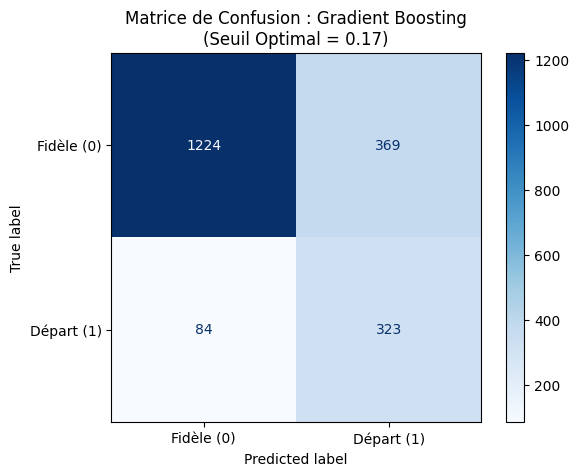


--- RAPPORT DE CLASSIFICATION (SEUIL OPTIMISÉ) ---
              precision    recall  f1-score   support

           0       0.94      0.77      0.84      1593
           1       0.47      0.79      0.59       407

    accuracy                           0.77      2000
   macro avg       0.70      0.78      0.72      2000
weighted avg       0.84      0.77      0.79      2000



In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Récupération du meilleur modèle (Gradient Boosting)
# Si vous utilisez la liste 'resultats_finaux' du code précédent :
best_gb_model = resultats_finaux[0]['Modèle_Objet']
seuil_optimal = 0.170202

# 2. Calcul des prédictions basées sur le seuil
# On ne prend pas .predict() car il utilise 0.5 par défaut
probs = best_gb_model.predict_proba(X_test)[:, 1]
y_pred_custom = (probs >= seuil_optimal).astype(int)

# 3. Création de la matrice de confusion
cm = confusion_matrix(Y_test, y_pred_custom)

# 4. Affichage visuel
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fidèle (0)', 'Départ (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matrice de Confusion : Gradient Boosting\n(Seuil Optimal = {seuil_optimal:.2f})")
plt.show()

# 5. Rapport détaillé
print("\n--- RAPPORT DE CLASSIFICATION (SEUIL OPTIMISÉ) ---")
print(classification_report(Y_test, y_pred_custom))

In [21]:
import pickle
import os

# Création du dossier artifacts s'il n'existe pas [cite: 16]
os.makedirs('artifacts', exist_ok=True)

# 1. Sauvegarde du modèle final (Gradient Boosting) [cite: 22, 46]
with open('artifacts/model.pickle', 'wb') as f:
    pickle.dump(best_gb_model, f)

# 2. Sauvegarde du preprocessor complet (Encoding + Scaling) [cite: 23, 46]
# Cet objet sait quelles colonnes transformer et comment
with open('artifacts/scaler.pickle', 'wb') as f:
    pickle.dump(preprocessor, f)

# 3. Sauvegarde de la liste des noms de colonnes attendues en entrée
# Pour s'assurer que l'API reçoit les données dans le bon ordre
input_columns = X_raw.columns.tolist()
with open('artifacts/input_columns.pickle', 'wb') as f:
    pickle.dump(input_columns, f)

# 4. Sauvegarde de la sélection de variables (votre "embedding") [cite: 24, 46]
with open('artifacts/pca.pickle', 'wb') as f:
    pickle.dump(selected_features, f)

print("Tous les artefacts de la pipeline ont été sauvegardés.")

Tous les artefacts de la pipeline ont été sauvegardés.
